<a href="https://colab.research.google.com/github/AliAch04/TPs_python/blob/Trait_img%2FTP1/TP1_traitement_d'image_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 : Analyse d’image

## 1. Correction de luminance (Histogram Stretching)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

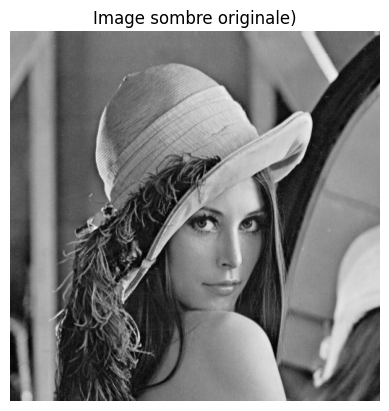

In [ ]:
img = cv2.imread('/dark_lena.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title("Image sombre originale)")
plt.axis('off')
plt.show()

Réponse 1.1 :
L’image est très sombre
Les détails sont difficilement visibles

L’image apparaît sombre (faible luminance).
 Les détails sont difficiles à distinguer.
 La majorité des pixels sont proches du noir.

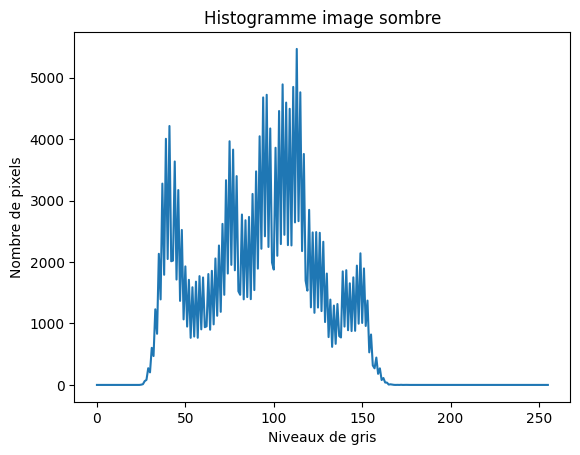

In [ ]:
hist = cv2.calcHist([img], [0], None, [256], [0,256])

plt.plot(hist)
plt.title("Histogramme image sombre")
plt.xlabel("Niveaux de gris")
plt.ylabel("Nombre de pixels")
plt.show()

Réponse 1.2 :
Histogramme concentré vers les faibles intensités (0–100)
→ cohérent avec image sombre

L’histogramme est concentré vers les faibles valeurs (proche de 0).
 Cela signifie que la plupart des pixels sont sombres.

Oui, cela est cohérent avec l’observation visuelle :
 Image sombre → histogramme à gauche

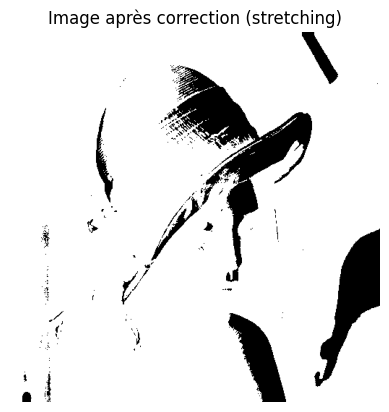

In [ ]:
min_val = np.min(img)
max_val = np.max(img)

stretched = (img - min_val) * 255 / (max_val - min_val)
stretched = stretched.astype(np.uint8)

plt.imshow(stretched, cmap='gray')
plt.title("Image après correction (stretching)")
plt.axis('off')
plt.show()

Réponse 1.4 :
On applique une normalisation linéaire
Étire les intensités entre 0 et 255

Le stretching améliore la luminance mais peut provoquer une saturation des pixels si les valeurs extrêmes sont présentes. Une version améliorée consiste à utiliser des seuils ou l’égalisation d’histogramme

PARTIE 2 : Correction de contraste (Histogram Equalization)

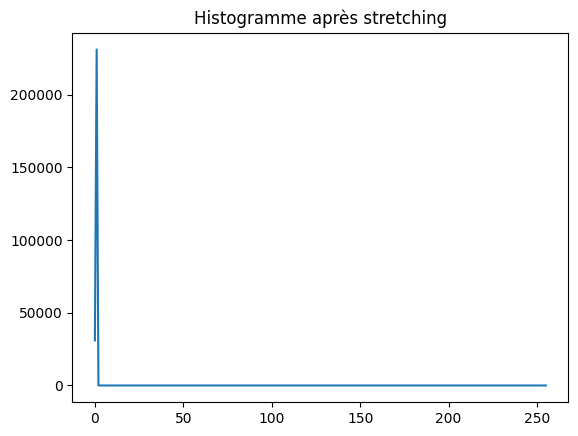

In [ ]:
hist_stretched = cv2.calcHist([stretched], [0], None, [256], [0,256])

plt.plot(hist_stretched)
plt.title("Histogramme après stretching")
plt.show()

Réponse 1.5 :
Histogramme étalé sur toute la plage
→ meilleure luminosité

# 2. Correction du contraste (Histogram Equalization)

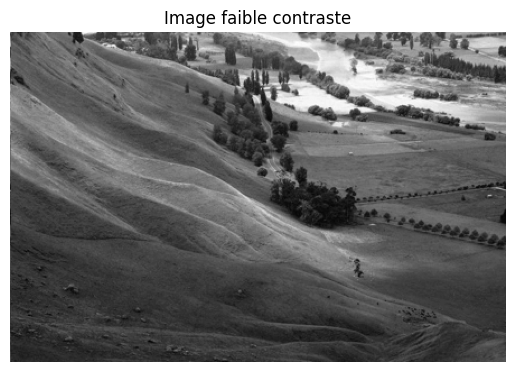

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img2 = cv2.imread('/weak_contrasted.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(img2, cmap='gray')
plt.title("Image faible contraste")
plt.axis('off')
plt.show()


 L’image présente un faible contraste
Les niveaux de gris sont très proches → image “fade”

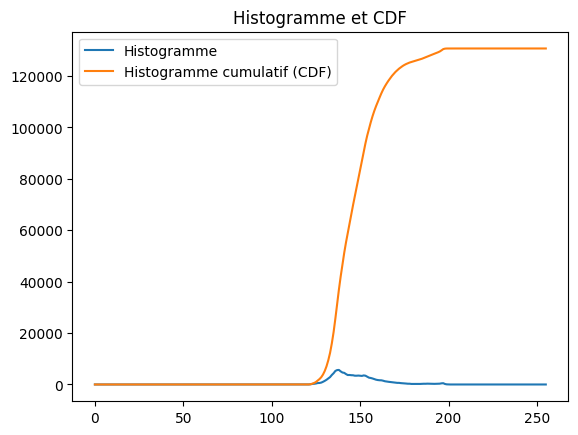

In [ ]:
hist = cv2.calcHist([img2], [0], None, [256], [0,256])
cdf = hist.cumsum()

plt.plot(hist, label="Histogramme")
plt.plot(cdf, label="Histogramme cumulatif (CDF)")
plt.legend()
plt.title("Histogramme et CDF")
plt.show()

### Normalisation du CDF

In [ ]:
cdf_normalized = (cdf / cdf.max()) * 255
cdf_normalized = cdf_normalized.astype(np.uint8)

### Égalisation manuelle

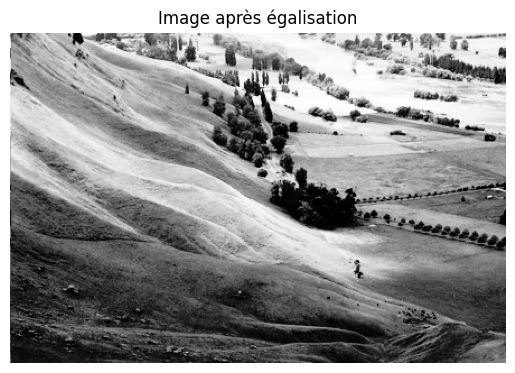

In [ ]:
equalized = cdf_normalized[img2]

plt.imshow(equalized, cmap='gray')
plt.title("Image après égalisation")
plt.axis('off')
plt.show()

### Histogramme après égalisation

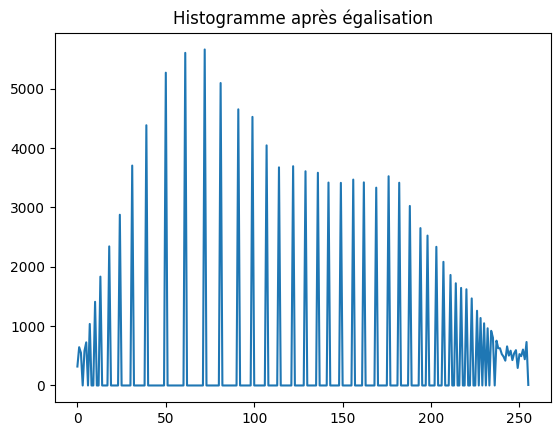

In [ ]:
hist_eq = cv2.calcHist([equalized], [0], None, [256], [0,256])

plt.plot(hist_eq)
plt.title("Histogramme après égalisation")
plt.show()

Réponse 2.5 :
Histogramme devient plus uniforme
Répartition des pixels améliorée

Le CDF agit comme une fonction de transformation qui redistribue les intensités → améliore contraste

### Comparaison Stretching vs Equalization

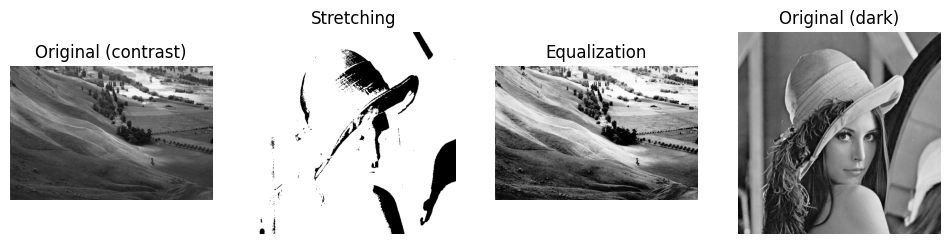

In [ ]:
plt.figure(figsize=(12,4))

# Image originale (faible contraste)
plt.subplot(1,4,1)
plt.imshow(img2, cmap='gray')
plt.title("Original (contrast)")
plt.axis('off')

# Stretching
plt.subplot(1,4,2)
plt.imshow(stretched, cmap='gray')
plt.title("Stretching")
plt.axis('off')

# Equalization
plt.subplot(1,4,3)
plt.imshow(equalized, cmap='gray')
plt.title("Equalization")
plt.axis('off')

# Image sombre (autre cas)
plt.subplot(1,4,4)
plt.imshow(img, cmap='gray')
plt.title("Original (dark)")
plt.axis('off')

plt.show()

Réponse 2.6 :
 Equalization meilleur que stretching seul
 Combiner les deux peut améliorer encore
 Mais parfois peut créer du bruit

# 3. Correction du contraste — Image couleur

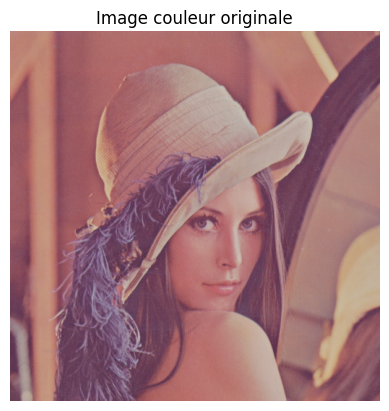

In [ ]:
img_color = cv2.imread('/weak_colored_contrast.png')
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

plt.imshow(img_color)
plt.title("Image couleur originale")
plt.axis('off')
plt.show()

### Conversion vers YCrCb

In [ ]:
img_ycrcb = cv2.cvtColor(img_color, cv2.COLOR_RGB2YCrCb)
y, cr, cb = cv2.split(img_ycrcb)

### Égalisation sur luminance (Y)

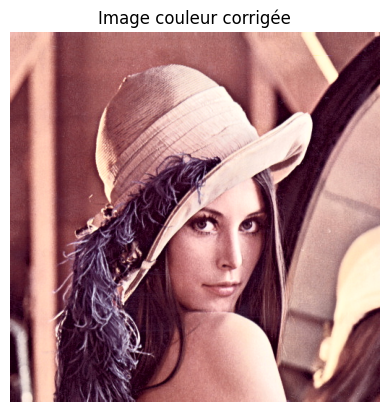

In [ ]:
y_eq = cv2.equalizeHist(y)

img_eq = cv2.merge([y_eq, cr, cb])
img_eq = cv2.cvtColor(img_eq, cv2.COLOR_YCrCb2RGB)

plt.imshow(img_eq)
plt.title("Image couleur corrigée")
plt.axis('off')
plt.show()

Conclusion générale :
Histogramme = outil clé pour analyser image
Stretching → corrige luminosité
Equalization → corrige contraste
Pour couleur → traiter seulement la luminance (Y)